# Comparison between the Fourier space and Real space analysis:

In [18]:
import logging

import os

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from tools import run_profiling_one_mock

In [19]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    """ 
    """
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax} 
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax   }   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']

    return propose_fiducial


def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR', nmocks_mean=None, 
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None, nmocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]
    if nmocks is not None:
        kwargs['nmocks'] = nmocks

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    if nmocks_mean is not None:
        # Keep only mocks that are not used in the mean, to have independent mocks for covariance validation and likelihood profiling.
        mean_mock = lsstypes.mean(mock[:nmocks_mean])
        mock = mock[nmocks_mean:]

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    if nmocks_mean is not None:
        return pk, window, cov, zeff, mock, mean_mock
    else:
        return pk, window, cov, zeff, mock

In [20]:
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

region = 'GCcomb'
fiducial = propose_fiducial(kmin=1e-3, region=region)
tracers_to_read = ['LRG', 'QSO']
window_extra = 'RIC+AMR'
extra_fn = '_' + window_extra if window_extra else ''

pks, windows, covs, zeffs, mocks = {}, {}, {}, {}, {}
alternative_mocks = {}
for tt in tracers_to_read:
    print(f"Loading data for {tt}...")
    tmp = 'x'.join([tt[:3], tt[:3]]) if 'x' not in tt else tt.replace('notqso', '')
    print(f"Loading data for {tt} ({tmp}) with extra_fn={extra_fn}...")
    pks[tmp], windows[tmp], covs[tmp], zeffs[tmp], mocks[tmp] = load_data(data_dir, mocks_dir, tt, fiducial, window_extra=window_extra)

Loading data for LRG...
Loading data for LRG (LRGxLRG) with extra_fn=_RIC+AMR...
Loading data for QSO...
Loading data for QSO (QSOxQSO) with extra_fn=_RIC+AMR...


In [21]:
import tqdm
import itertools

base_dir = mocks_dir.replace('summary_statistics', 'profiles') + f"/holi-v3-altmtl/"

# tracers = ['LRGxLRG']
# kmin = [{'LRGxLRG': 4e-3}]

## BAD CODING HERE ... -> OKOK let's go 

tracers = ['LRGxLRG']
kmin = [{'LRGxLRG': 4e-3}, {'LRGxLRG': 6e-3}]

# Do you want to rerun the profiling even if the output file already exists?
force_profiling = False
# Save the bestfit plot?
save_plot = False

analytical_covariances = [False]
drop_ell2_cross = False

nmocks = range(800, 900)

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, nmocks, kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

print(itertools.product(tracers, kmin))

resu = {}
for tt in tracers:
    resu[tt] = {}
    for kk in kmin:
        print(tt, kk[tt])
        resu[tt][kk[tt]] = []


for t, i, kk, ac in tqdm.tqdm(jobs):
    result = run_profiling_one_mock(mocks, windows, covs, t, region=region, imock=i, alternative_mocks=alternative_mocks, drop_ell2_cross=drop_ell2_cross,
                        kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
                        base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiles=True, save_plot=False)
    if result is None: 
        result = np.load(base_dir + f"mock{i}/bestfit_{t}_{region}_{'analytical_cov' if ac else 'mock_cov'}_kmin-{kk[t]:.0e}{extra_fn}.npy")
    resu[t][kk[t]].append(result)


tracers = ['QSOxQSO']
kmin = [{'QSOxQSO': 2e-3}]
# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, nmocks, kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

for tt in tracers:
    resu[tt] = {}
    for kk in kmin:
        print(tt, kk[tt])
        resu[tt][kk[tt]] = []

for t, i, kk, ac in tqdm.tqdm(jobs):
    result = run_profiling_one_mock(mocks, windows, covs, t, region=region, imock=i, alternative_mocks=alternative_mocks, drop_ell2_cross=drop_ell2_cross,
                        kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
                        base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiles=True, save_plot=False)
    if result is None: 
        result = np.load(base_dir + f"mock{i}/bestfit_{t}_{region}_{'analytical_cov' if ac else 'mock_cov'}_kmin-{kk[t]:.0e}{extra_fn}.npy")
    resu[t][kk[t]].append(result)

200 jobs to run
LRGxLRG 0.004
LRGxLRG 0.006


100%|██████████| 200/200 [00:00<00:00, 4206.21it/s]


100 jobs to run
QSOxQSO 0.002


100%|██████████| 100/100 [00:00<00:00, 3686.91it/s]


In [22]:
fnl, fnl_err = {}, {}
for tt in ['LRGxLRG', 'QSOxQSO']:
    fnl[tt], fnl_err[tt] = {}, {}

    kk_list = [4e-3, 6e-3] if tt == 'LRGxLRG' else [2e-3]
    for kk in kk_list:
        try: 
            fnl[tt][kk] = [float(rr.to_stats(tablefmt="list")[0][3][1]) for rr in resu[tt][kk]]
            fnl_err[tt][kk] = [float(rr.to_stats(tablefmt="list")[0][3][2]) for rr in resu[tt][kk]]
        except Exception as e:
            #print(f"Error processing results for {tt} with kmin={kk}: {e}")
            fnl[tt][kk] = [float(resu[tt][kk][i][3][1]) for i in range(len(resu[tt][kk]))]
            fnl_err[tt][kk] = [float(rr[3][2]) for rr in resu[tt][kk]]

In [23]:
import fitsio 

#('mean', '>f8'), ('sigma_plus', '>f8'), ('sigma_minus', '>f8'), ('sigma_avg', '>f8')]
lrg_2pcf = fitsio.FITS('data_tmp/holi_LRG_seed800_899.fits')[1].read()
lrg_2pcf_fid = fitsio.FITS('data_tmp/holi_LRG_seed800_899_smax340_fiducial.fits')[1].read()

qso_2pcf_fid = fitsio.FITS('data_tmp/holi_QSO_seed800_899_smax400fiducial.fits')[1].read()

LRGxLRG 0.004 0.9858640559978117
LRGxLRG 0.006 0.8789223710969047
QSOxQSO 0.002 0.7439000702343181


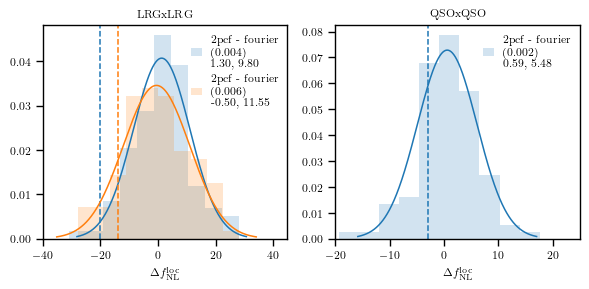

In [26]:
from scipy.stats import norm

plt.figure(figsize=(6, 3))

plt.subplot(121)

tt = 'LRGxLRG'
for kk in [4e-3, 6e-3]:
    mu, sigma = np.mean(lrg_2pcf_fid['mean'] - fnl[tt][kk]), np.std(lrg_2pcf_fid['mean'] - fnl[tt][kk])
    plt.hist(lrg_2pcf_fid['mean'] - fnl[tt][kk], density=1, color='C0' if kk == 4e-3 else 'C1', alpha=0.2, label=f'2pcf - fourier \n ({kk:.3f}) \n {mu:.2f}, {sigma:.2f}')
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 500)
    pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    plt.plot(x, pdf, color='C0' if kk == 4e-3 else 'C1', ls='-', lw=1.1)
    if kk == 4e-3:
        print(tt, kk, norm.sf(5 - 25.2, loc=mu, scale=sigma))
        plt.axvline(5 - 25.2, ls='--', c='C0')
    elif kk == 6e-3:
        print(tt, kk, norm.sf(5 - 19, loc=mu, scale=sigma))
        plt.axvline(5 - 19, ls='--', c='C1')

plt.xlim(-40,45)
#plt.grid(alpha=0.2)
plt.legend(ncol=1, loc='upper right')
plt.title(tt)
plt.xlabel(r'$\Delta f_{\rm NL}^{\rm loc}$')


plt.subplot(122)

tt = 'QSOxQSO'
for kk in [2e-3]:
    mu, sigma = np.mean(qso_2pcf_fid['mean'] - fnl[tt][kk]), np.std(qso_2pcf_fid['mean'] - fnl[tt][kk])
    plt.hist(qso_2pcf_fid['mean'] - fnl[tt][kk], density=1, color='C0', alpha=0.2, label=f'2pcf - fourier \n ({kk:.3f}) \n {mu:.2f}, {sigma:.2f}')
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 500)
    pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    plt.plot(x, pdf, color='C0', ls='-', lw=1.1)

    print(tt, kk, norm.sf(-7 - (-4.0), loc=mu, scale=sigma))
    plt.axvline(-7 - (-4.0), ls='--', c='C0')

plt.xlim(-20,25)
#plt.grid(alpha=0.2)
plt.legend(ncol=1, loc='upper right')
plt.title(tt)
plt.xlabel(r'$\Delta f_{\rm NL}^{\rm loc}$')


plt.tight_layout()
plt.savefig('fig_fourier_real_comparison.png', dpi=400)
plt.show()


1.4636266645745113 6.473292207101022
1.704995463606649 6.172328290832174
0.40500000000000014 11.780690769220623
9.082672858407227 1.5395295840821202
9.571505957769958 1.8860408380854015
12.03 2.047999023437267
1.0586266645745115 10.045586890510705


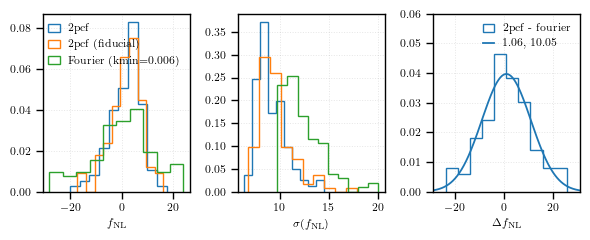

In [105]:
plt.figure(figsize=(6, 2.5))
plt.subplot(131)

plt.hist(lrg_2pcf['mean'], histtype='step', density=1, label='2pcf')
print(np.mean(lrg_2pcf['mean']), np.std(lrg_2pcf['mean']))

plt.hist(lrg_2pcf_fid['mean'], histtype='step', density=1, label='2pcf (fiducial)')
print(np.mean(lrg_2pcf_fid['mean']), np.std(lrg_2pcf_fid['mean']))

plt.hist(fnl[4e-3], histtype='step', density=1, label='Fourier (kmin=0.006)')
print(np.mean(fnl[4e-3]), np.std(fnl[4e-3]))
plt.grid(alpha=0.2)
plt.legend()
plt.xlabel(r'$f_{\rm NL}$')

plt.subplot(132)
plt.hist(lrg_2pcf['sigma_avg'], histtype='step', density=1, label='2pcf')
print(np.mean(lrg_2pcf['sigma_avg']), np.std(lrg_2pcf['sigma_avg']))

plt.hist(lrg_2pcf_fid['sigma_avg'], histtype='step', density=1, label='2pcf (fiducial)')
print(np.mean(lrg_2pcf_fid['sigma_avg']), np.std(lrg_2pcf_fid['sigma_avg']))

plt.hist(fnl_err[4e-3], histtype='step', density=1, label='Fourier (kmin=0.006)')
print(np.mean(fnl_err[4e-3]), np.std(fnl_err[4e-3]))
plt.xlabel(r'$\sigma(f_{\rm NL})$')
plt.grid(alpha=0.2)

plt.subplot(133)
plt.hist(lrg_2pcf['mean'] - fnl[4e-3],  color='C0', density=1, histtype='step', label='2pcf - fourier')
mu, sigma = np.mean(lrg_2pcf['mean'] - fnl[4e-3]), np.std(lrg_2pcf['mean'] - fnl[4e-3])
print(mu, sigma)
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 500)
pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
plt.plot(x, pdf, color='C0', ls='-', lw=1.3, label=f'{mu:.2f}, {sigma:.2f}')

plt.xlim(mu - 3 * sigma, mu + 3 * sigma)
plt.grid(alpha=0.2)
plt.legend()
plt.ylim(0, 0.06)
plt.xlabel(r'$\Delta f_{\rm NL}$')

plt.tight_layout()
plt.show()
